In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload


In [1]:
import sys
import numpy as np 
import pandas as pd
from pathlib import Path
from src.phaseI.main import run_phase1
from src.phaseII.main import run_phase2

from demo.core.data import (
    SplitConfig,
    prepare_cmapss_split,
)

config = SplitConfig(
    # ========================================================
    # Dataset
    # ========================================================
    data_path="demo/data/train_FD001.txt",
    random_seed=42,

    # ========================================================
    # Train / Test split
    # ========================================================
    train_ratio=0.70,

    # ========================================================
    # Observation cutoff
    # ========================================================
    observation_cycle_min=130,
    observation_cycle_max=135,

    # ========================================================
    # Rare fault
    # ========================================================
    rare_fault_probability=0.20,

    rare_fault_max_duration=10,

    rare_fault_max_start_before_cutoff=20,

    rare_fault_magnitude_min=3.0,
    rare_fault_magnitude_max=6.0,   

    rare_fault_types=(
        "plateau",
        "drop",
        "drift",
    ),

    # ========================================================
    # Test realtime
    # ========================================================
    test_fraction_min=0.10,
    test_fraction_max=0.30,
)

data = prepare_cmapss_split(config)


In [2]:
import numpy as np


# ============================================================
# 1. BASIC STATISTICS
# ============================================================

print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)

print(f"Total engines : {len(data['engine_data'])}")
print(f"Train engines : {len(data['train_data'])}")
print(f"Test engines  : {len(data['test_data'])}")
print(f"Sensors       : {data['sensors']}")


# ============================================================
# 2. TRAIN OBSERVATION LENGTH
# ============================================================

train_lengths = []

for engine_id, trajectory in data["train_data"].items():
    train_lengths.append(len(trajectory))

print("\n" + "=" * 60)
print("TRAIN OBSERVATION LENGTH")
print("=" * 60)

print(f"Min  : {min(train_lengths)}")
print(f"Max  : {max(train_lengths)}")
print(f"Mean : {np.mean(train_lengths):.2f}")
print(f"Std  : {np.std(train_lengths):.2f}")


# ============================================================
# 3. CHECK THAT WE NEVER EXTENDED TRAJECTORY
# ============================================================

print("\n" + "=" * 60)
print("TRAJECTORY LENGTH CHECK")
print("=" * 60)

violations = []

for engine_id in data["train_ids"]:

    original_length = len(
        data["engine_data"][engine_id]
    )

    observed_length = len(
        data["train_data"][engine_id]
    )

    if observed_length > original_length:
        violations.append(
            (engine_id, original_length, observed_length)
        )

print(
    f"Extended trajectories : {len(violations)}"
)

if violations:
    print("WARNING:")
    for item in violations:
        print(item)
else:
    print("PASS - No trajectory was extended.")


# ============================================================
# 4. RARE FAULT STATISTICS
# ============================================================

metadata = data["train_metadata"]

fault_engines = [
    engine_id
    for engine_id, meta in metadata.items()
    if meta["has_rare_fault"]
]

normal_engines = [
    engine_id
    for engine_id, meta in metadata.items()
    if not meta["has_rare_fault"]
]

print("\n" + "=" * 60)
print("RARE FAULT STATISTICS")
print("=" * 60)

print(f"Normal engines     : {len(normal_engines)}")
print(f"Rare-fault engines : {len(fault_engines)}")

fault_ratio = len(fault_engines) / len(metadata)

print(f"Fault ratio        : {fault_ratio:.2%}")


# ============================================================
# 5. FAULT TYPE DISTRIBUTION
# ============================================================

fault_types = {}

for engine_id in fault_engines:

    fault_type = metadata[engine_id]["fault_type"]

    fault_types[fault_type] = (
        fault_types.get(fault_type, 0) + 1
    )

print("\nFault types:")

for fault_type, count in fault_types.items():
    print(f"  {fault_type:<10}: {count}")


# ============================================================
# 6. AFFECTED SENSOR DISTRIBUTION
# ============================================================

fault_sensors = {}

for engine_id in fault_engines:

    sensor = metadata[engine_id]["fault_sensor"]

    fault_sensors[sensor] = (
        fault_sensors.get(sensor, 0) + 1
    )

print("\nAffected sensors:")

for sensor, count in sorted(
    fault_sensors.items(),
    key=lambda x: -x[1],
):
    print(f"  {sensor:<6}: {count}")


# ============================================================
# 7. FAULT DURATION
# ============================================================

fault_durations = [
    metadata[engine_id]["fault_duration"]
    for engine_id in fault_engines
]

if fault_durations:

    print("\n" + "=" * 60)
    print("RARE FAULT DURATION")
    print("=" * 60)

    print(f"Min  : {min(fault_durations)}")
    print(f"Max  : {max(fault_durations)}")
    print(f"Mean : {np.mean(fault_durations):.2f}")


# ============================================================
# 8. FAULT POSITION
# ============================================================

print("\n" + "=" * 60)
print("RARE FAULT POSITION")
print("=" * 60)

for engine_id in fault_engines[:10]:

    meta = metadata[engine_id]

    print(
        f"Engine {engine_id:>3} | "
        f"observed={meta['observed_cycles']:>3} | "
        f"fault={meta['fault_type']:<8} | "
        f"sensor={meta['fault_sensor']:<5} | "
        f""
        f"{meta['fault_start']:>3}"
        f"→"
        f"{meta['fault_end']:>3}"
    )


# ============================================================
# 9. TEST INITIAL OBSERVATION
# ============================================================

test_fractions = []

for engine_id, observed in data["test_data"].items():

    total = len(
        data["engine_data"][engine_id]
    )

    observed_length = len(observed)

    test_fractions.append(
        observed_length / total
    )

print("\n" + "=" * 60)
print("TEST INITIAL OBSERVATION")
print("=" * 60)

print(f"Min  : {min(test_fractions):.3f}")
print(f"Max  : {max(test_fractions):.3f}")
print(f"Mean : {np.mean(test_fractions):.3f}")

print(
    "\nExpected range: "
    f"{config.test_fraction_min:.2f}"
    f" → "
    f"{config.test_fraction_max:.2f}"
)

BASIC STATISTICS
Total engines : 100
Train engines : 70
Test engines  : 30
Sensors       : ['T24', 'T30', 'T50', 'P30', 'Ps30', 'phi', 'BPR', 'W31', 'W32']

TRAIN OBSERVATION LENGTH
Min  : 128
Max  : 135
Mean : 132.11
Std  : 1.70

TRAJECTORY LENGTH CHECK
Extended trajectories : 0
PASS - No trajectory was extended.

RARE FAULT STATISTICS
Normal engines     : 54
Rare-fault engines : 16
Fault ratio        : 22.86%

Fault types:
  drift     : 5
  drop      : 7
  plateau   : 4

Affected sensors:
  T50   : 6
  T24   : 2
  W32   : 2
  phi   : 2
  P30   : 1
  T30   : 1
  Ps30  : 1
  W31   : 1

RARE FAULT DURATION
Min  : 2
Max  : 10
Mean : 5.62

RARE FAULT POSITION
Engine   4 | observed=135 | fault=drift    | sensor=T50   | 130→134
Engine  10 | observed=132 | fault=drop     | sensor=T24   | 112→114
Engine  11 | observed=134 | fault=drop     | sensor=W32   | 114→124
Engine  19 | observed=133 | fault=drop     | sensor=P30   | 110→115
Engine  40 | observed=133 | fault=drift    | sensor=T24   | 124

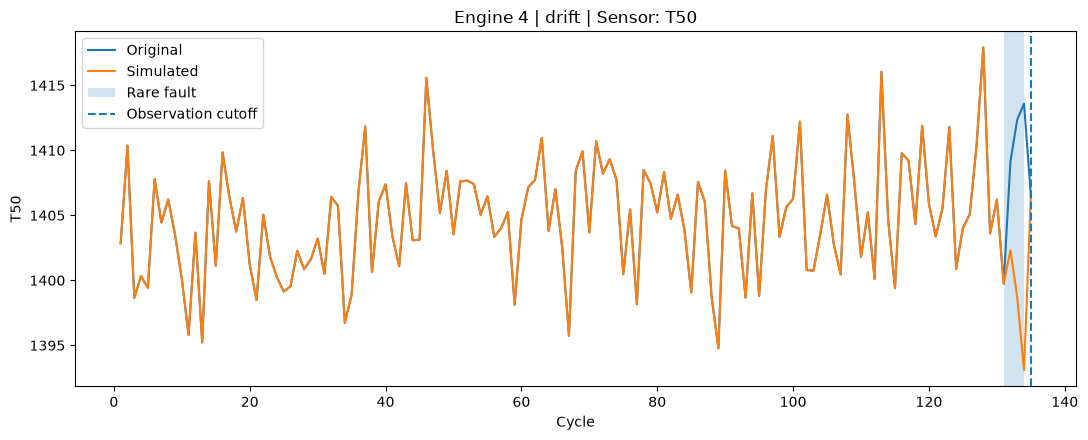

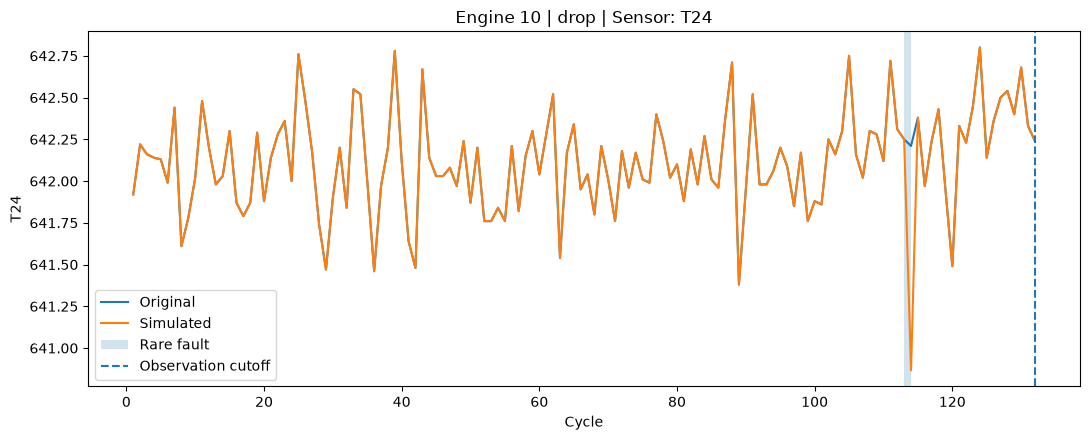

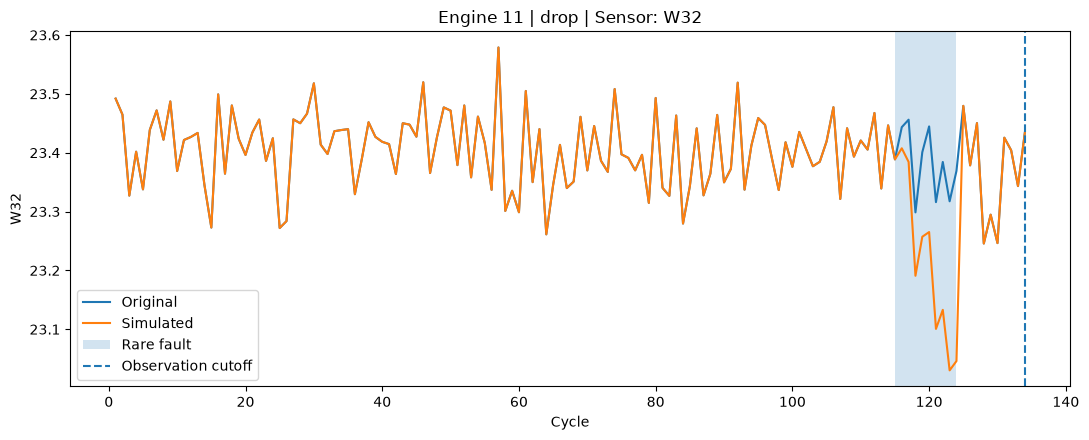

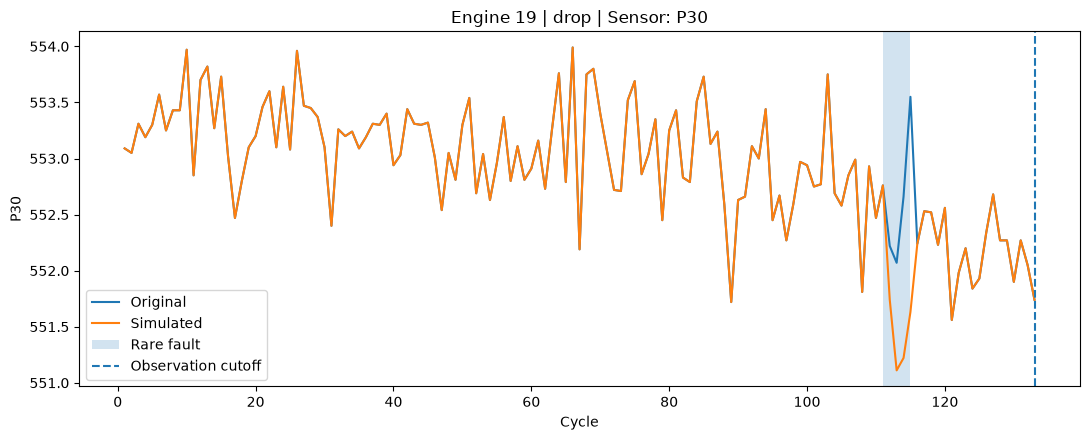

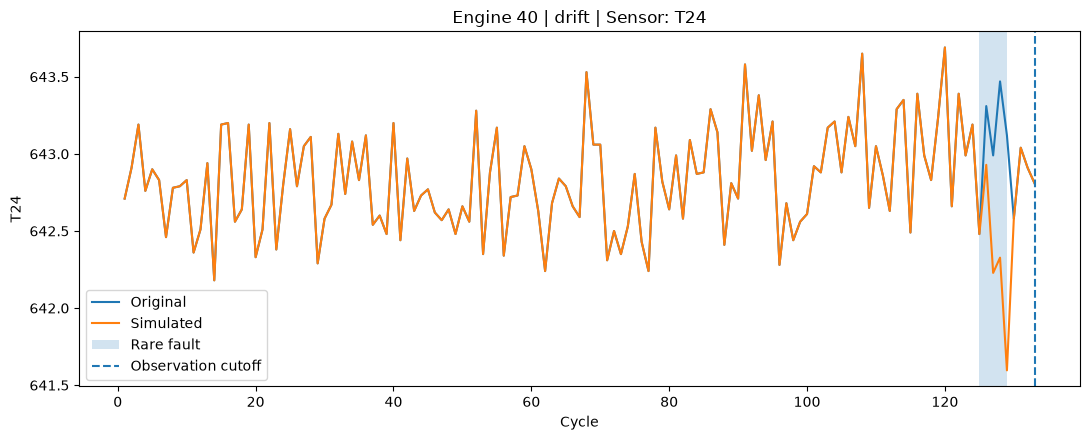

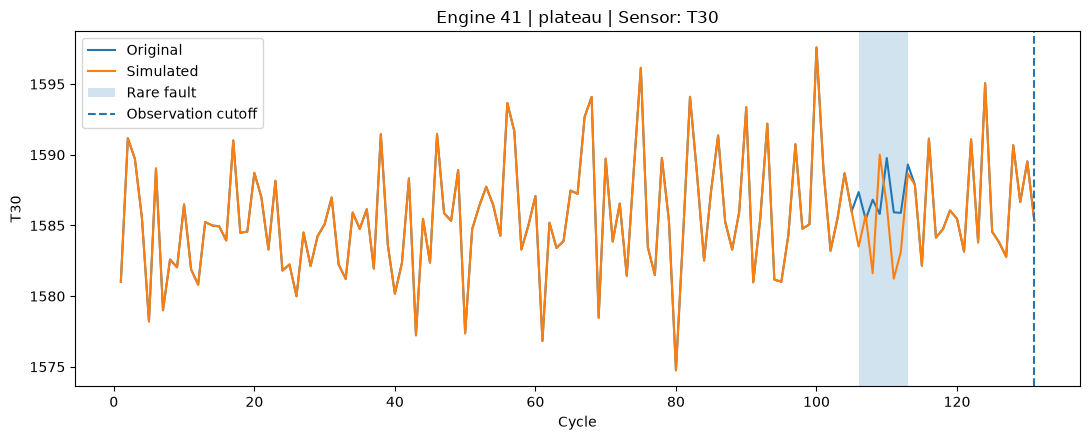

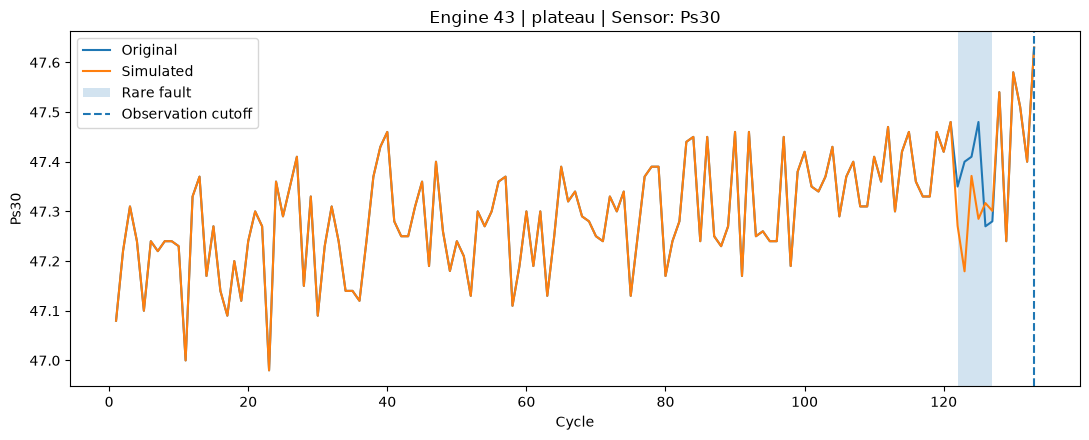

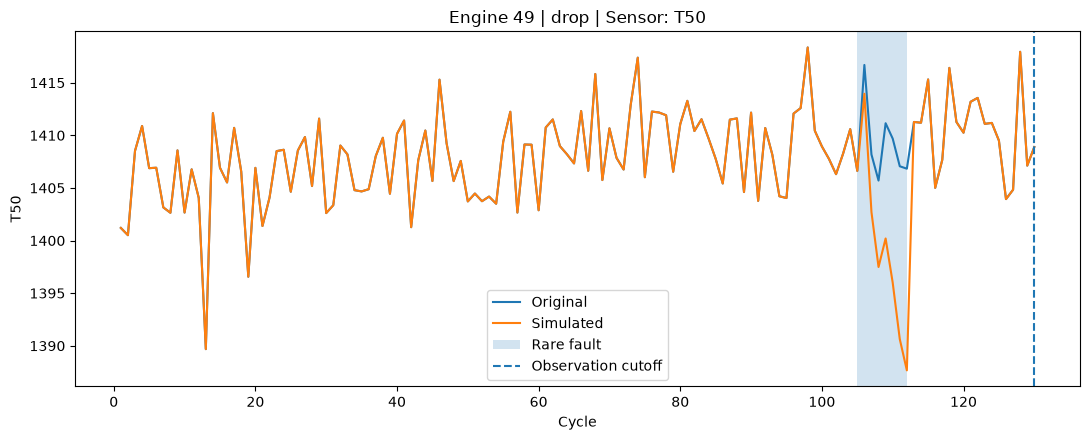

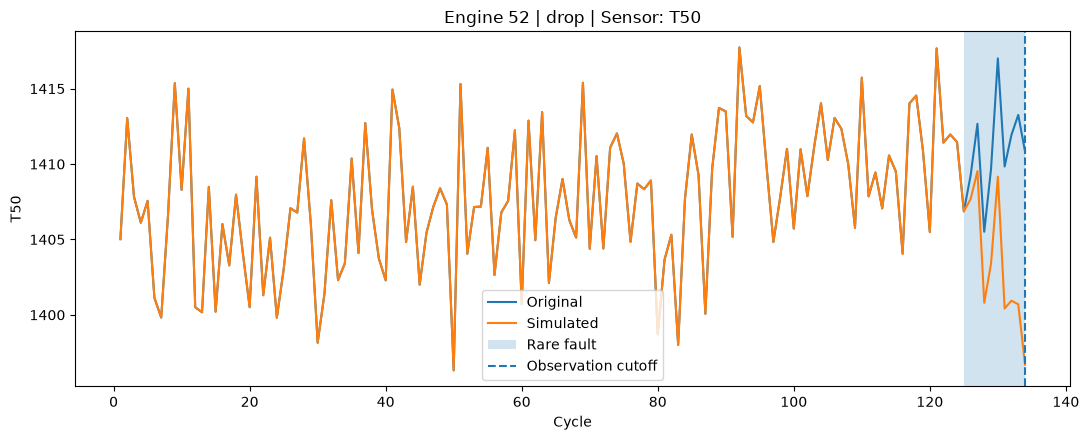

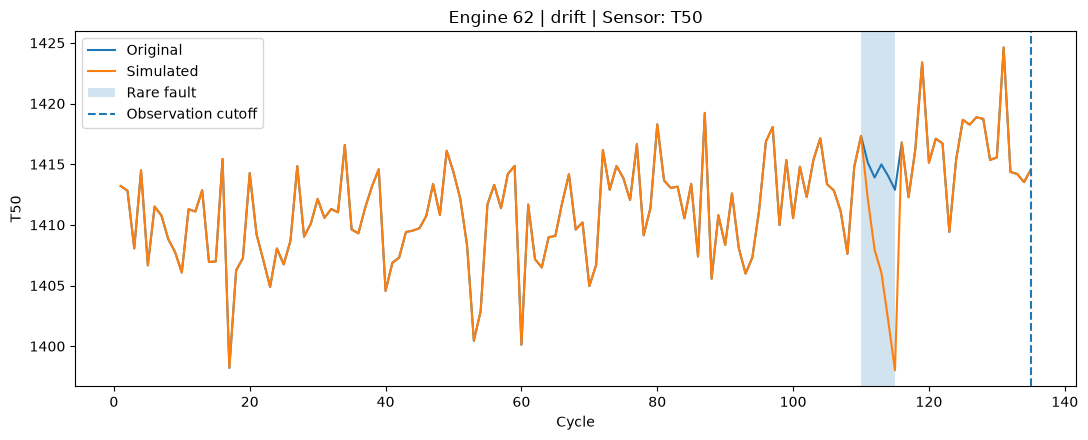

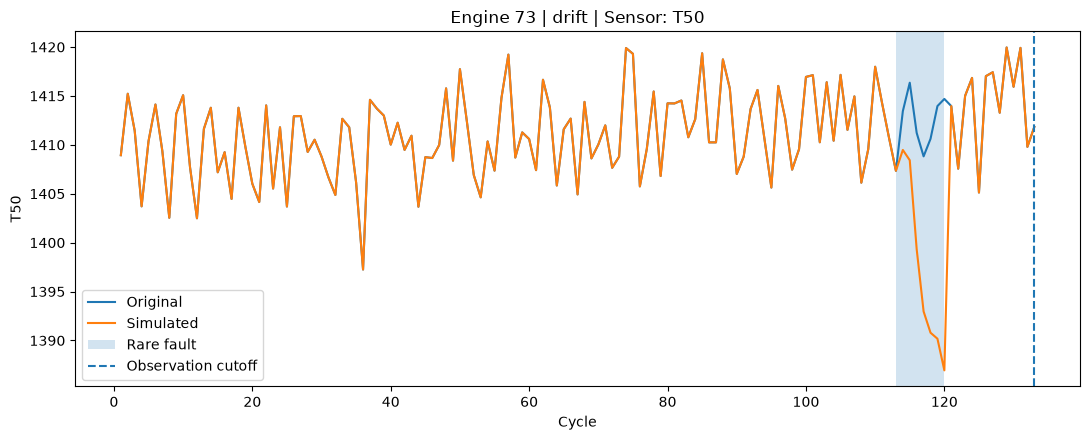

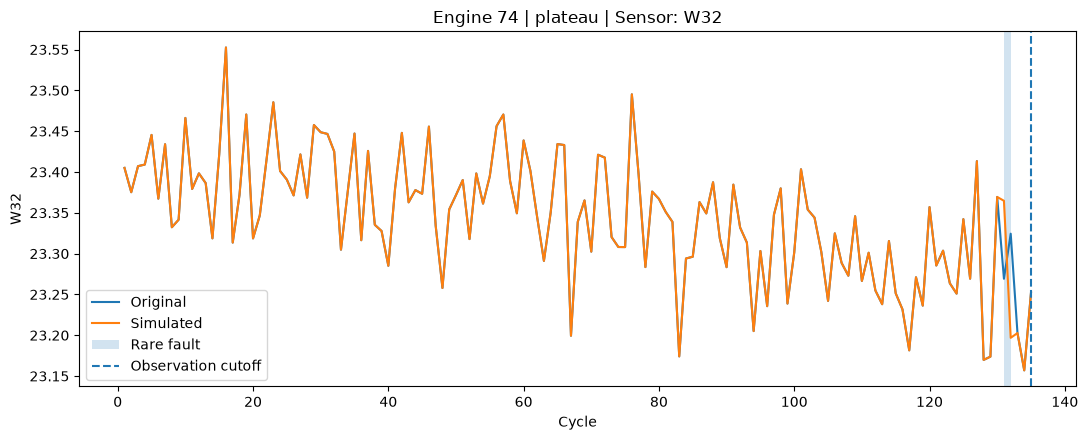

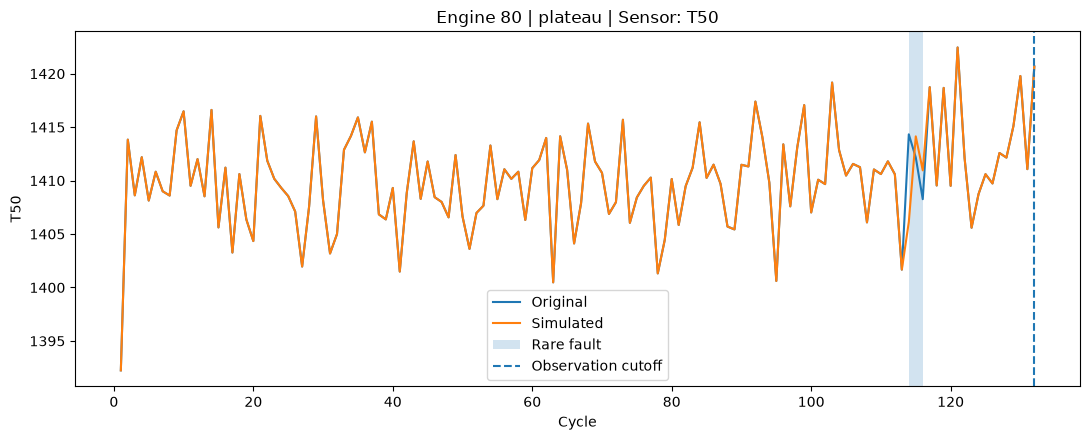

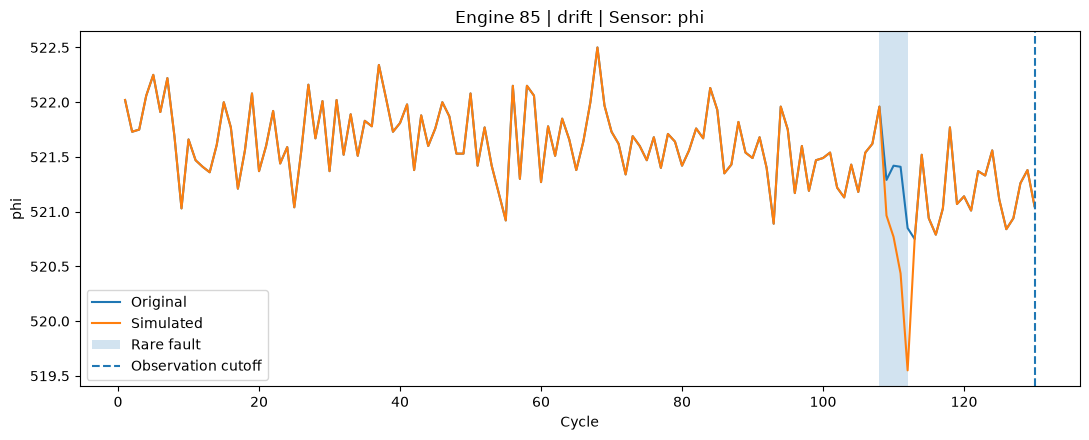

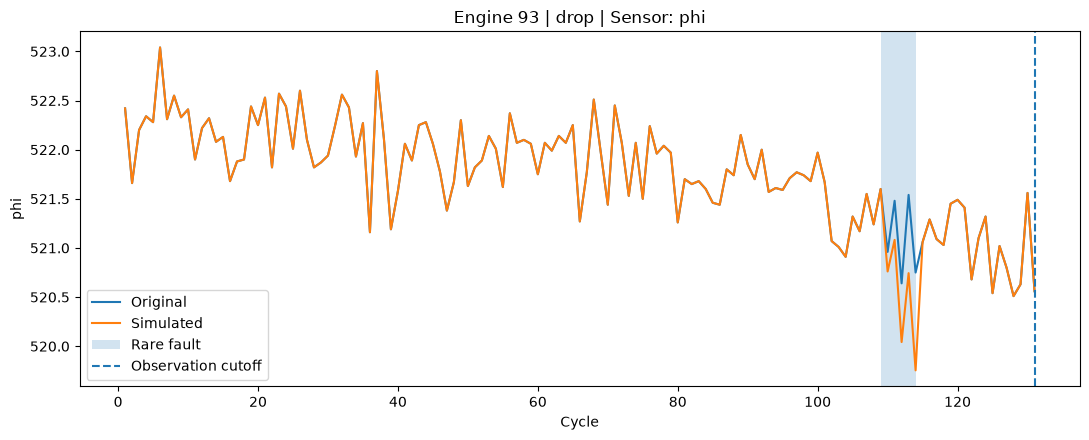

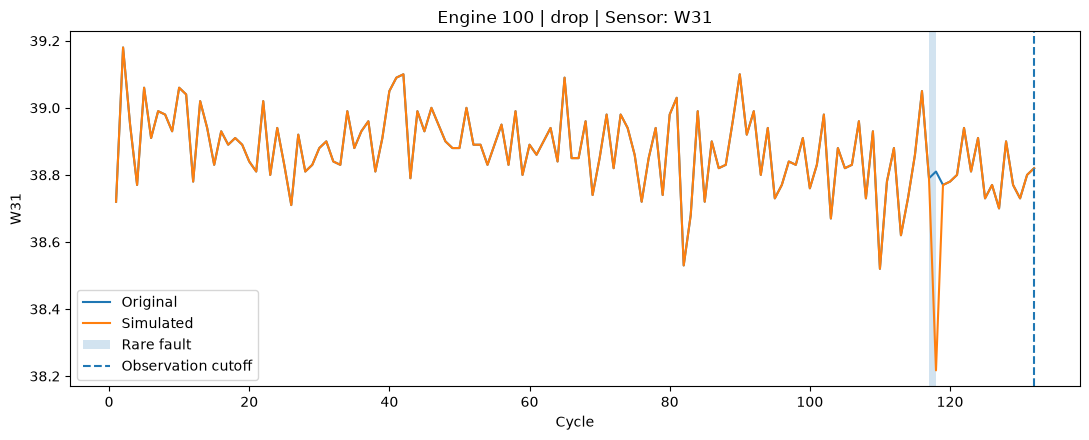

In [5]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Chọn các engine có rare fault
# ============================================================

fault_engines = [
    engine_id
    for engine_id, meta in data["train_metadata"].items()
    if meta["has_rare_fault"]
]

selected_engines = fault_engines[:]


# ============================================================
# Plot
# ============================================================

for engine_id in selected_engines:

    meta = data["train_metadata"][engine_id]

    original = data["engine_data"][engine_id]
    simulated = data["train_data"][engine_id]

    sensor_idx = meta["fault_sensor_index"]
    sensor_name = meta["fault_sensor"]

    observed_length = len(simulated)

    cycles = np.arange(1, observed_length + 1)

    plt.figure(figsize=(11, 4.5))

    # Original trajectory
    plt.plot(
        cycles,
        original[:observed_length, sensor_idx],
        label="Original",
    )

    # Simulated trajectory
    plt.plot(
        cycles,
        simulated[:, sensor_idx],
        label="Simulated",
    )

    # Rare fault region
    plt.axvspan(
        meta["fault_start"] + 1,
        meta["fault_end"],
        alpha=0.2,
        label="Rare fault",
    )

    # Observation cutoff
    plt.axvline(
        observed_length,
        linestyle="--",
        label="Observation cutoff",
    )

    plt.xlabel("Cycle")
    plt.ylabel(sensor_name)

    plt.title(
        f"Engine {engine_id} | "
        f"{meta['fault_type']} | "
        f"Sensor: {sensor_name}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 1000x400 with 0 Axes>

In [ ]:
from src.preprocess_data.realtime import (
    simulate_realtime,
    RealtimeConfig,
)

realtime = simulate_realtime(
    engine_data=data["engine_data"],
    test_data=data["test_data"],
    observation_points=data["test_observation_points"],
    config=RealtimeConfig(
        update_probability=0.8,
        max_new_cycles=1,
        random_seed=42,
    ),
)


In [3]:
BIN_STRIDE = 10

model, stats, normalized_data, latent_data = run_phase1(
    train_data=data["train_data"],
    n_sensors=len(data["sensors"]),
    window_len=30,
    latent_dim=16,
    bin_stride=BIN_STRIDE,
)


epoch   0 | recon_loss=0.641268
epoch   1 | recon_loss=0.459071
epoch   2 | recon_loss=0.455278
epoch   3 | recon_loss=0.452914
epoch   4 | recon_loss=0.451605
epoch   5 | recon_loss=0.449937
epoch   6 | recon_loss=0.448773
epoch   7 | recon_loss=0.447074
epoch   8 | recon_loss=0.444165
epoch   9 | recon_loss=0.442259
epoch  10 | recon_loss=0.440754
epoch  11 | recon_loss=0.438643
epoch  12 | recon_loss=0.436481
epoch  13 | recon_loss=0.434676
epoch  14 | recon_loss=0.432115
epoch  15 | recon_loss=0.428120
epoch  16 | recon_loss=0.423622
epoch  17 | recon_loss=0.420929
epoch  18 | recon_loss=0.419783
epoch  19 | recon_loss=0.418983
epoch  20 | recon_loss=0.418373
epoch  21 | recon_loss=0.417992
epoch  22 | recon_loss=0.417828
epoch  23 | recon_loss=0.417501
epoch  24 | recon_loss=0.417374
epoch  25 | recon_loss=0.417133
epoch  26 | recon_loss=0.417036
epoch  27 | recon_loss=0.416860
epoch  28 | recon_loss=0.416732
epoch  29 | recon_loss=0.416614


In [5]:
from src.phaseII.core.prepare_data import build_engine_records
records = build_engine_records(
    latent_data=latent_data,
    train_metadata=data["train_metadata"],
)

In [6]:
print("\n=== ENGINE RECORDS ===")

for record in records:
    print(
        f"engine={record.engine_id:>3} | "
        f"shape={record.latent_seq.shape} | "
        f"n_bins={record.n_bins:>3} | "
        f"event_observed={record.event_observed} | "
        f"event_bin={record.event_bin}"
    )


=== ENGINE RECORDS ===
engine=  1 | shape=(11, 16) | n_bins= 11 | event_observed=False | event_bin=None
engine=  2 | shape=(10, 16) | n_bins= 10 | event_observed=False | event_bin=None
engine=  3 | shape=(10, 16) | n_bins= 10 | event_observed=False | event_bin=None
engine=  4 | shape=(12, 16) | n_bins= 12 | event_observed=True | event_bin=11
engine=  5 | shape=(15, 16) | n_bins= 15 | event_observed=True | event_bin=14
engine=  6 | shape=(10, 16) | n_bins= 10 | event_observed=False | event_bin=None
engine=  8 | shape=(11, 16) | n_bins= 11 | event_observed=False | event_bin=None
engine= 10 | shape=(11, 16) | n_bins= 11 | event_observed=False | event_bin=None
engine= 11 | shape=(10, 16) | n_bins= 10 | event_observed=False | event_bin=None
engine= 16 | shape=(15, 16) | n_bins= 15 | event_observed=True | event_bin=14
engine= 17 | shape=(11, 16) | n_bins= 11 | event_observed=True | event_bin=10
engine= 18 | shape=(10, 16) | n_bins= 10 | event_observed=False | event_bin=None
engine= 19 | sha